In [ ]:
import sys, os, time, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import ipywidgets as widgets

from src.ddsp import MultiScaleSpectralLoss
from src.ddsp.dataset import WavClipDataset
from src.fm_ddsp import DDSPFMModel, DDSPFMModelFlex
from src.training_divergence import (
    VoiceSynth, fit_synth_to_target, load_esc50_animals,
    load_audio_chunks, make_probe_trajectory, make_probe_from_clip,
    finetune_step, save_divergent_checkpoint,
)
from src.training_divergence.finetune_utils import save_inharmonic_checkpoint
from torch.utils.data import DataLoader

SAMPLE_RATE  = 16000
HOP_LENGTH   = 64
MODELS_DIR   = '../models'
TMP_DIR      = '../tmp'           # divergent checkpoints are saved here
FM_CKPT      = os.path.join(MODELS_DIR, 'fm_violin.pt')
VIOLIN_DIR   = '../samples/violin'
TRUMPET_DIR  = '../samples/trumpet'
ESC50_DIR    = '../samples/esc50'


def load_fm_baseline(freeze=True):
    ckpt  = torch.load(FM_CKPT, map_location='cpu', weights_only=False)
    model = DDSPFMModel(**ckpt['config'])
    model.load_state_dict(ckpt['model_state_dict'])
    if freeze:
        model.eval()
        for p in model.parameters():
            p.requires_grad_(False)
    return model, ckpt['config']


def specshow(audio, sr=16000, title='', ax=None, fmax=8000.0):
    import librosa, librosa.display
    wav = audio.squeeze().detach().cpu().numpy()
    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=(8, 2.5))
    D = librosa.amplitude_to_db(
        np.abs(librosa.stft(wav, n_fft=1024, hop_length=256)), ref=np.max)
    librosa.display.specshow(D, sr=sr, hop_length=256,
                              x_axis='time', y_axis='log', ax=ax, fmax=fmax)
    ax.set_title(title)
    if own:
        plt.tight_layout()
        plt.show()


def play(audio, sr=16000, normalize=True):
    wav = audio.squeeze().detach().cpu().numpy()
    if normalize and np.abs(wav).max() > 1e-8:
        wav = wav / np.abs(wav).max() * 0.9
    display(Audio(wav, rate=sr))


os.makedirs(TMP_DIR, exist_ok=True)
print('Setup complete.')
print(f'  FM checkpoint:  {FM_CKPT}  — exists: {os.path.exists(FM_CKPT)}')
print(f'  Violin clips:   {VIOLIN_DIR}  — {len([f for f in os.listdir(VIOLIN_DIR) if f.endswith(".wav")])} WAV files')
print(f'  Trumpet clips:  {TRUMPET_DIR}  — {len([f for f in os.listdir(TRUMPET_DIR) if f.endswith(".wav")])} WAV files')
print(f'  ESC-50 clips:   {ESC50_DIR}/audio  — {len(os.listdir(ESC50_DIR + "/audio"))} files')
print(f'  Checkpoint dir: {TMP_DIR}')

# Notebook 3: Training-Time Active Divergence

*Class: Active Divergence with Generative Deep Learning*

---

In Notebook 2 we modified a **frozen** model at inference time — bending its outputs without
changing its weights. This notebook goes deeper: we **change training itself** to deliberately
introduce divergence.

Broad et al. identify three major training-time mechanisms:

| Mechanism | Description |
|-----------|-------------|
| **Inspiring set** | Target distribution chosen to be *outside* what the synthesizer can faithfully reproduce — approximation creates novelty |
| **Domain drift / fine-tuning** | Continue training on foreign audio; model drifts toward a hybrid timbre |
| **Loss modification** | Rewarding properties the original training signal actively discourages |

All three produce **irreversible** changes to the model's internal world — new weights, not just
new inputs.

### Three techniques
1. **§3.1 Inspiring Set** — Hagiwara et al.: optimise a limited modular synth against animal vocalizations
2. **§3.2 Divergent Fine-tuning** — Fine-tune the DDSP violin model on EMF electrical noise
3. **§3.3 Loss Hacking** — Add an inharmonicity term to the objective; hear the violin drift toward metallic tones


---
## §3.1  Inspiring Set: Animal Vocalizations via a Limited Synthesizer

### Background — Hagiwara et al. (2022)

Hagiwara et al. synthesize animal vocalizations with **TorchSynth Voice** — a modular
synthesizer with ~74 parameters: two VCOs (sine + sawtooth), a noise generator, six
ADSR envelopes, two LFOs with their own ADSRs, a 4×5 modulation matrix, and an audio
mixer.  Since TorchSynth requires a broken pytorch-lightning version on Python 3.12,
we use a faithful pure-PyTorch re-implementation (`VoiceSynth`).

The key idea: the synthesizer is **intentionally limited**.  It cannot reproduce
clicks, harmonic trills, or tonal complexity above a single MIDI pitch.  Gradient
descent finds parameters that echo the target's most prominent acoustic feature while
filling the rest with synthesizer artefacts — the **inspiring-set effect**.

**Optimization**: Adam, 200 iterations, lr=0.001 (exactly as in the paper).


In [ ]:
print("Loading animal vocalizations ...")
animals = load_esc50_animals(
    ESC50_DIR,
    categories={"cat", "frog", "chirping_birds", "crickets"},
    max_per_category=1,
    duration=2.0,
    sample_rate=SAMPLE_RATE,
)
print(f"Loaded {len(animals)} clips:")
for a in animals:
    print(f"  {a['category']:18s}  {a['filename']}")

### Optimization — 200 steps per clip (exactly as in Hagiwara et al.)

Adam, lr=0.001, multi-scale STFT loss.  Parameters are initialised uniformly at random
before each fit — different animals start from the same distribution but converge to
different local minima because their spectral targets differ.

After fitting, compare spectrograms: VoiceSynth captures broad pitch register and
temporal envelope but loses biological texture.  That loss is the creative gap.


In [ ]:
fitted = []

for item in animals:
    cat = item['category']
    print(f"\n── Fitting: {cat} ({item['filename']}) ──")
    synth, losses = fit_synth_to_target(
        item['audio'],
        n_iter=1000,
        lr=0.08,
        sample_rate=SAMPLE_RATE,
        verbose=True,
    )
    with torch.no_grad():
        approx = synth()
    p = synth.get_param_dict()
    print(f"  → f0={p['midi_hz']:.0f}Hz  vco2={p['vco2_detune_st']:+.1f}st  "
          f"shape={p['vco2_shape']:.2f}  lfo1={p['lfo1_rate_hz']:.1f}Hz  "
          f"mix=({p['mix_vco1']:.2f},{p['mix_vco2']:.2f},{p['mix_noise']:.2f})")
    fitted.append({
        "category": cat, "filename": item['filename'],
        "target": item['audio'], "approx": approx, "losses": losses,
        "synth": synth,
    })


In [ ]:
# ── Spectrogram comparison + loss curves ─────────────────────────────────────
n = len(fitted)
fig, axes = plt.subplots(n, 3, figsize=(15, 3.0 * n))
if n == 1: axes = axes[None, :]

for row, item in enumerate(fitted):
    ax_t, ax_a, ax_l = axes[row]
    specshow(item['target'], title=f"{item['category']} — TARGET",       ax=ax_t)
    specshow(item['approx'], title=f"{item['category']} — SYNTH APPROX", ax=ax_a)
    ax_l.plot(item['losses'], lw=1.5, color='steelblue')
    ax_l.set(xlabel='Iteration', ylabel='Spectral loss', title='Optimization loss')
    ax_l.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ── Audio playback ────────────────────────────────────────────────────────────
for item in fitted:
    print(f"\n{'─'*55}")
    print(f"Category: {item['category']}  |  {item['filename']}")
    print("  Target:")
    play(item['target'])
    print("  Synth approximation:")
    play(item['approx'])


### Fitted parameters

VoiceSynth has ~74 parameters — too many for a hand-controlled slider panel.
Instead, inspect what the optimizer settled on for each animal and listen to the results.
The key observable parameters are: f0 (MIDI pitch → Hz), VCO2 detune and shape
(sine→sawtooth), LFO rates (tremolo/vibrato speed), and the final mixer weights.


In [ ]:
if not fitted:
    print("Run optimization cells above first.")
else:
    import pandas as pd
    rows = []
    for r in fitted:
        p = r['synth'].get_param_dict()
        rows.append({
            'animal': r['category'],
            'f0 (Hz)': p['midi_hz'],
            'vco2 detune (st)': p['vco2_detune_st'],
            'vco2 shape': p['vco2_shape'],
            'lfo1 (Hz)': p['lfo1_rate_hz'],
            'lfo2 (Hz)': p['lfo2_rate_hz'],
            'mix vco1': p['mix_vco1'],
            'mix vco2': p['mix_vco2'],
            'mix noise': p['mix_noise'],
        })
    try:
        display(pd.DataFrame(rows).set_index('animal').round(3))
    except ImportError:
        for row in rows:
            print(row)


---
## §3.2  Divergent Fine-tuning: Violin FM → Trumpet

### Concept: Domain Drift via Fine-tuning

Fine-tuning the FM violin model on **trumpet** audio (another URMP instrument) forces
the decoder to re-learn operator envelopes for a different spectral character.
The FM ratios [14, 3, 1, 1, 1, 1] are fixed — but the decoder learns to *weight*
the operators differently: trumpet uses much higher modulation indices than violin
(bright, brassy upper partials), so Ops 0 and 1 (the deep modulators) are emphasised.

A fixed violin probe (real f0 + loudness from a violin clip) is rendered at every
checkpoint.  Comparing these probes over steps reveals how the *same input* produces
increasingly trumpet-like output — the model is maladapted to violin, creative in output.

Trumpet was chosen because:
- Same URMP dataset → matched recording conditions
- Same pitch range (overlaps with violin G3–E6)
- Very different timbre: brassy vs. bowed-string spectra differ in harmonic envelope shape
  and modulation index profile


In [ ]:
SOURCE_TAG = 'violin'
TARGET_TAG = 'trumpet'

n_clips = len([f for f in os.listdir(TRUMPET_DIR) if f.endswith('.wav')]) if os.path.isdir(TRUMPET_DIR) else 0
print(f'Trumpet clips: {n_clips}')
print(f'FM checkpoint: {FM_CKPT} — exists: {os.path.exists(FM_CKPT)}')

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
BATCH_SIZE = 2
N_EPOCHS   = 10
LR         = 5e-4
SAVE_EVERY = 200   # checkpoint every 200 steps → ~10 probe snapshots
FFT_SIZES_FT = (2048, 1024, 512, 256)

# ── Probe: real violin clip ───────────────────────────────────────────────────
PROBE_CLIP_IDX = 5
probe_f0, probe_loud, probe_ref_audio = make_probe_from_clip(
    VIOLIN_DIR, clip_idx=PROBE_CLIP_IDX)
print(f'Probe: f0 {probe_f0.min():.0f}–{probe_f0.max():.0f} Hz')
print('\nOriginal violin audio (reference):')
play(probe_ref_audio)

# ── Trumpet dataset ───────────────────────────────────────────────────────────
tpt_ds = WavClipDataset(TRUMPET_DIR)
tpt_loader = DataLoader(tpt_ds, batch_size=BATCH_SIZE, shuffle=True,
                         collate_fn=WavClipDataset.collate_fn, drop_last=True)
print(f'\nTrumpet clips: {len(tpt_ds)}')

# ── FM model + optimiser ──────────────────────────────────────────────────────
ft_model, ft_config = load_fm_baseline(freeze=False)
ft_model.train()

# Freeze the noise branch so it cannot compensate for FM changes.
# Only the shared GRU/MLP encoder, the FM envelope head, and reverb are trained.
for p in ft_model.decoder.noise_head.parameters():
    p.requires_grad_(False)
for p in ft_model.noise_synth.parameters():
    p.requires_grad_(False)

trainable = [p for p in ft_model.parameters() if p.requires_grad]
ft_optimizer = torch.optim.Adam(trainable, lr=LR)
ft_criterion = MultiScaleSpectralLoss(fft_sizes=FFT_SIZES_FT)
print(f'FM model params total:     {sum(p.numel() for p in ft_model.parameters()):,}')
print(f'  of which trainable (FM): {sum(p.numel() for p in trainable):,}')
print('Ready — violin probe above; compare to probes below.')

### Fine-tuning loop

After every `SAVE_EVERY` steps: save a checkpoint and render the probe.
The probe uses the real violin f0/loudness, so you hear the exact same musical gesture
played through progressively more divergent model weights.


In [ ]:
ft_probe_audios = []
ft_loss_history = []
ft_step = 0
data_iter = iter(tpt_loader)


@torch.no_grad()
def render_probe(model):
    model.eval()
    n2s = 2 * SAMPLE_RATE // HOP_LENGTH
    audio = model(probe_f0[:, :n2s], probe_loud[:, :n2s])['audio'].squeeze()
    model.train()
    return audio


ft_probe_audios.append(('step 0 (baseline)', render_probe(ft_model)))
steps_per_epoch = len(tpt_ds) // BATCH_SIZE
print(f'Baseline probe rendered.')
print(f'Starting: {N_EPOCHS} epochs × {steps_per_epoch} steps/epoch\n')

t_start = time.time()
for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    for _ in range(steps_per_epoch):
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(tpt_loader)
            batch = next(data_iter)

        # Loss on fm_audio only — noise branch is frozen and cannot compensate
        lv = finetune_step(ft_model, ft_optimizer, ft_criterion, batch,
                           output_key='fm_audio')
        ft_loss_history.append((ft_step, lv))
        epoch_loss += lv
        ft_step += 1
        if ft_step % SAVE_EVERY == 0:
            pa = render_probe(ft_model)
            ft_probe_audios.append((f'step {ft_step}', pa))
            ckpt = save_divergent_checkpoint(
                ft_model, ft_step, SOURCE_TAG, TARGET_TAG, TMP_DIR, ft_config)
            print(f'  ✓ {os.path.basename(ckpt)}')
    print(f'Epoch {epoch+1}/{N_EPOCHS}  avg={epoch_loss/steps_per_epoch:.4f}  '
          f'elapsed={time.time()-t_start:.0f}s')

print(f'\nDone. Steps: {ft_step}')

In [ ]:
# ── Loss curve ────────────────────────────────────────────────────────────────
if ft_loss_history:
    steps, vals = zip(*ft_loss_history)
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(steps, vals, lw=1.2, color='crimson', alpha=0.8)
    ax.set(xlabel='Step', ylabel='Spectral loss', title='Fine-tuning loss — violin → Trumpet')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# ── Probe spectrogram strip ───────────────────────────────────────────────────
n_p = len(ft_probe_audios)
if n_p:
    fig, axes = plt.subplots(1, n_p, figsize=(4 * n_p, 3), sharey=True)
    if n_p == 1: axes = [axes]
    for ax, (label, audio) in zip(axes, ft_probe_audios):
        specshow(audio, title=label, ax=ax)
    plt.suptitle('Probe output — same real violin f0/loudness through changing weights', y=1.02)
    plt.tight_layout()
    plt.show()


In [ ]:
# ── Listen to divergence accumulating ────────────────────────────────────────
print("Original violin audio (for comparison):")
play(probe_ref_audio[:2*SAMPLE_RATE])

for label, audio in ft_probe_audios:
    print(f"  {label}:")
    play(audio)


---
## §3.3  Loss Hacking: FM Operator Restlessness

### Concept

The FM decoder outputs **6 operator envelopes** per frame — amplitude weights that
directly control the modulation index of each FM operator.  Violin training made
these envelopes smooth and correlated: they all gently track the loudness input.

The loss hack rewards the exact opposite — **maximum frame-to-frame change** in
every operator envelope:

> `loss = −mean |Δenvelope|`

Note what is absent: `batch['audio']` never appears.  The violin dataset provides
only the `(f0, loudness)` conditioning.  The loss has nothing to do with sounding
like violin — it only cares about the operator envelopes varying as much as possible.

The decoder, previously trained to produce smooth, correlated envelopes, now learns
to make each operator flicker independently at the maximum rate the GRU can support.
Rapidly alternating operator amplitudes produce internal FM amplitude modulation —
the sideband structure of each operator is constantly gaining and losing energy.
The result is a buzzing, restless, metallic FM texture that no amount of violin
training could produce.

**Why this is loss hacking, not data modification:**
the data is unchanged; the loss function never looks at it.
A structural property of the FM synthesizer's own output is what drives the change.

In [6]:
# §3.3 — no saturation constant, no target audio, no custom loss class.
# The loss is one line operating on the FM operator envelopes.
print("§3.3: loss = -|Δoperator_envelope|  (batch['audio'] never used)")

§3.3: loss = -|Δoperator_envelope|  (batch['audio'] never used)


In [ ]:
# ── Probe: define if §3.2 was skipped ────────────────────────────────────────
if 'probe_f0' not in dir():
    probe_f0, probe_loud, probe_ref_audio = make_probe_from_clip(VIOLIN_DIR, clip_idx=5)

# ── §3.3 setup ────────────────────────────────────────────────────────────────
N_STEPS_HACK    = 50
LR_HACK         = 5e-4
SAVE_EVERY_HACK = 10

hack_model, hack_config = load_fm_baseline(freeze=False)
hack_model.train()

# Freeze noise branch — the hack targets FM operators, noise must not compensate
for p in hack_model.decoder.noise_head.parameters():
    p.requires_grad_(False)
for p in hack_model.noise_synth.parameters():
    p.requires_grad_(False)

trainable = [p for p in hack_model.parameters() if p.requires_grad]
hack_optimizer = torch.optim.Adam(trainable, lr=LR_HACK)

violin_ds     = WavClipDataset(VIOLIN_DIR)
violin_loader = DataLoader(violin_ds, batch_size=2, shuffle=True,
                            collate_fn=WavClipDataset.collate_fn, drop_last=True)

print(f'Trainable params: {sum(p.numel() for p in trainable):,}  (FM decoder + reverb)')
print(f'Steps: {N_STEPS_HACK},  LR: {LR_HACK}')
print(f'Loss: -|Δoperator_envelope| — no reference to batch[\'audio\']')

### Fine-tuning loop — violin data in, operator envelopes as the only loss signal

The batch audio is loaded but **never compared against**.  Only `f0_hz` and `loudness`
enter the model; the loss reads the resulting operator envelopes and rewards change.

In [10]:
hack_probe_audios = []
hack_loss_history = []
env_var_history   = []   # track how much envelopes are varying over training
hack_step = 0
data_iter = iter(violin_loader)


@torch.no_grad()
def render_hack_probe(model):
    model.eval()
    n2s = 2 * SAMPLE_RATE // HOP_LENGTH
    audio = model(probe_f0[:, :n2s], probe_loud[:, :n2s])['audio'].squeeze()
    model.train()
    return audio


hack_probe_audios.append(('step 0 (baseline)', render_hack_probe(hack_model)))
print('Baseline probe rendered.')
print(f'Starting §3.3: {N_STEPS_HACK} steps\n')

t_start = time.time()
for _ in range(N_STEPS_HACK):
    try:
        batch = next(data_iter)
    except StopIteration:
        data_iter = iter(violin_loader)
        batch = next(data_iter)

    hack_model.train()
    out = hack_model(batch['f0_hz'], batch['loudness'])

    # ── The loss hack — batch['audio'] is never used ───────────────────────
    envs = out['operator_envelopes']          # (B, N_ops, N_frames)
    loss = -envs.diff(dim=-1).abs().mean()    # maximise frame-to-frame change
    # ──────────────────────────────────────────────────────────────────────

    hack_optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(trainable, 1.0)
    hack_optimizer.step()

    hack_loss_history.append((hack_step, loss.item()))
    env_var_history.append((hack_step, -loss.item()))   # store positive: mean |Δenv|
    hack_step += 1

    if hack_step % SAVE_EVERY_HACK == 0:
        pa = render_hack_probe(hack_model)
        hack_probe_audios.append((f'step {hack_step}', pa))
        print(f'  step {hack_step:4d}  mean|Δenv|={-loss.item():.4f}  '
              f'elapsed={time.time()-t_start:.0f}s')

print(f'\nDone. {hack_step} steps.')

Baseline probe rendered.
Starting §3.3: 50 steps

  step   10  mean|Δenv|=0.0103  elapsed=2s
  step   20  mean|Δenv|=0.0214  elapsed=4s
  step   30  mean|Δenv|=0.0224  elapsed=6s
  step   40  mean|Δenv|=0.2651  elapsed=9s
  step   50  mean|Δenv|=0.3449  elapsed=11s

Done. 50 steps.


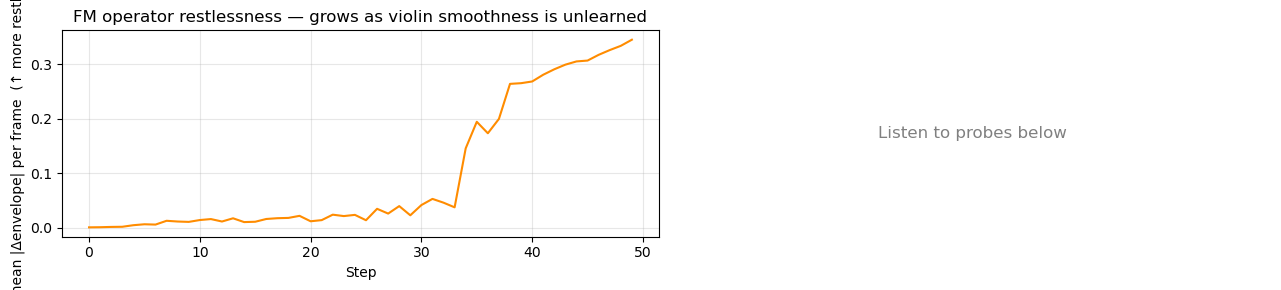

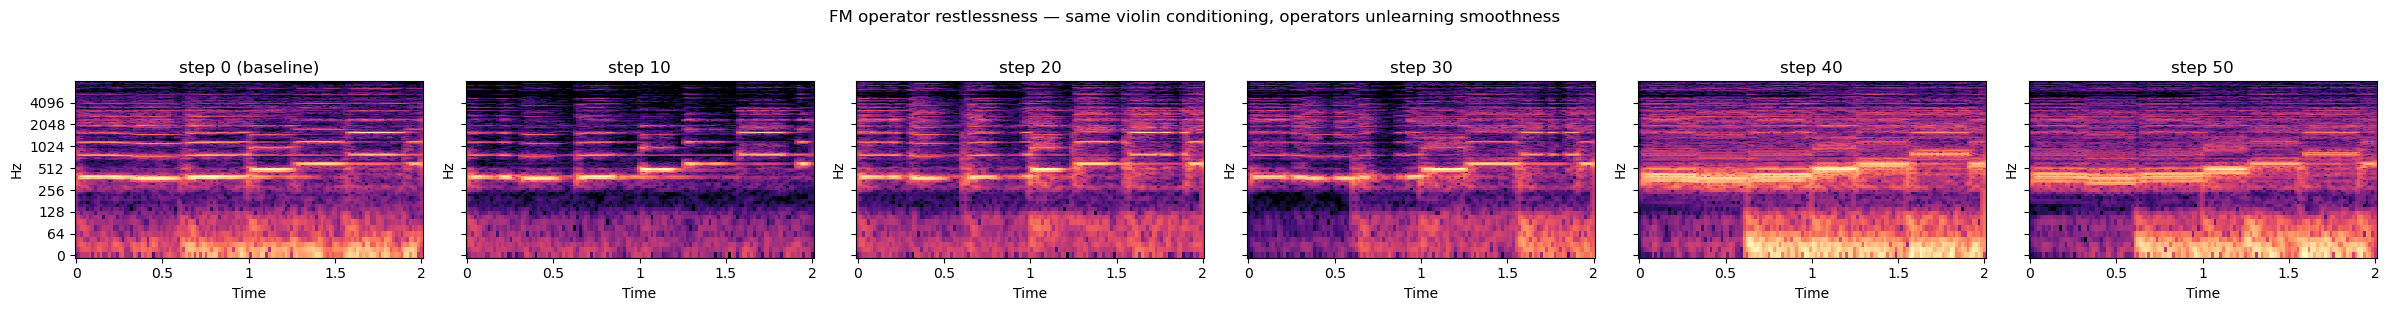

In [11]:
# ── Operator restlessness curve + probe spectrograms ─────────────────────────
if env_var_history:
    fig, axes = plt.subplots(1, 2, figsize=(13, 3))

    steps, vals = zip(*env_var_history)
    axes[0].plot(steps, vals, lw=1.5, color='darkorange')
    axes[0].set(xlabel='Step', ylabel='mean |Δenvelope| per frame  (↑ more restless)',
                title='FM operator restlessness — grows as violin smoothness is unlearned')
    axes[0].grid(True, alpha=0.3)

    n_p = len(hack_probe_audios)
    if n_p > 1:
        inner = axes[1].inset_axes([0, 0, 1, 1])
        inner.remove()
        # Reuse the figure for probe spectrograms if few probes, else separate figure
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'Listen to probes below', ha='center', va='center',
                 fontsize=12, color='grey')

    plt.tight_layout()
    plt.show()

# Probe spectrogram strip
n_p = len(hack_probe_audios)
if n_p:
    fig, axes = plt.subplots(1, n_p, figsize=(4 * n_p, 3), sharey=True)
    if n_p == 1: axes = [axes]
    for ax, (label, audio) in zip(axes, hack_probe_audios):
        specshow(audio, title=label, ax=ax)
    plt.suptitle('FM operator restlessness — same violin conditioning, operators unlearning smoothness',
                 y=1.02)
    plt.tight_layout()
    plt.show()

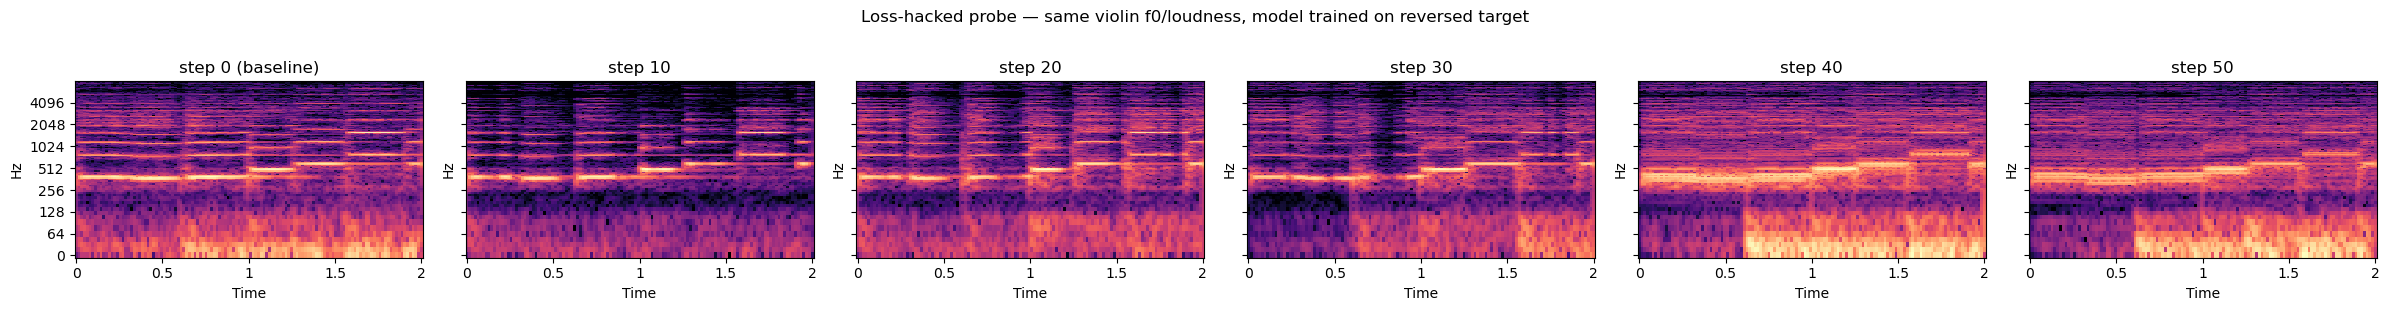

In [12]:
# ── Probe spectrogram strip ───────────────────────────────────────────────────
n_p = len(hack_probe_audios)
if n_p:
    fig, axes = plt.subplots(1, n_p, figsize=(4 * n_p, 3), sharey=True)
    if n_p == 1: axes = [axes]
    for ax, (label, audio) in zip(axes, hack_probe_audios):
        specshow(audio, title=label, ax=ax)
    plt.suptitle('Loss-hacked probe — same violin f0/loudness, model trained on reversed target',
                 y=1.02)
    plt.tight_layout()
    plt.show()

In [13]:
# ── Listen to divergence accumulating ────────────────────────────────────────
print("Original violin audio (for comparison):")
play(probe_ref_audio[:2*SAMPLE_RATE])

for label, audio in hack_probe_audios:
    print(f"  {label}:")
    play(audio)

Original violin audio (for comparison):


  step 0 (baseline):


  step 10:


  step 20:


  step 30:


  step 40:


  step 50:


---
## Summary

| Technique | What changes | The hack | Timbre trajectory |
|-----------|-------------|----------|-------------------|
| **§3.1 Inspiring Set** | Modular synth parameters | Target is animal vocalizations the synth cannot reproduce | Creative gap between target and output |
| **§3.2 Divergent Fine-tuning** | FM decoder weights | Same loss, different data (trumpet) | Progressive de-violining |
| **§3.3 Loss Hacking** | FM decoder weights | `loss = −\|Δoperator_envelope\|` — batch audio never used | Smooth violin → buzzing, restless FM texture |

### Key insight

§3.3 is the purest demonstration of **loss hacking**: the batch audio exists in memory
but the loss never reads it.  Only the FM operator envelopes matter.  The single
one-line objective — reward maximum frame-to-frame change in the 6 operators — is
enough to make the decoder unlearn its smooth, correlated violin behavior and produce
something that sounds nothing like what it was trained on.